In [2]:
# ============================================================
# 0. Montage de Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# ============================================================
# 1. Imports des librairies
# ============================================================

# outils système / fichiers
import os

# calcul numérique et dataframes
import numpy as np
import pandas as pd

# affichage
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras                      # modèle, utils, etc.
from tensorflow.keras import layers, models       # couches et modèles

# outils de scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


In [8]:
# ============================================================
# 2. Chemins vers les données GTSRB (Drive)
# ============================================================

# dossier racine du dataset GTSRB dans Google Drive
base_dir   = "/content/drive/MyDrive/archive/GTSRB"

# dossier contenant les images d'entraînement
train_dir  = os.path.join(base_dir, "Train")

# dossier contenant les images de test
test_dir   = os.path.join(base_dir, "Test")

# fichier CSV d'entraînement (chemins + labels)
train_csv  = os.path.join(base_dir, "Train.csv")

# fichier CSV de test (chemins + labels)
test_csv   = os.path.join(base_dir, "Test.csv")

# affichage des chemins pour vérification
print("train_dir :", train_dir)
print("test_dir  :", test_dir)
print("train_csv :", train_csv)
print("test_csv  :", test_csv)


train_dir : /content/drive/MyDrive/archive/GTSRB/Train
test_dir  : /content/drive/MyDrive/archive/GTSRB/Test
train_csv : /content/drive/MyDrive/archive/GTSRB/Train.csv
test_csv  : /content/drive/MyDrive/archive/GTSRB/Test.csv


In [9]:
# ============================================================
# 3. Chargement des images d'entraînement (GTSRB)
# ============================================================

# taille cible des images et nombre de classes du dataset
img_size    = 30
num_classes = 43

# listes pour stocker provisoirement les images et les labels
images = []
labels = []

# parcours des dossiers de classes : Train/0, Train/1, ..., Train/42
for class_id in range(num_classes):
    class_path = os.path.join(train_dir, str(class_id))  # dossier de la classe courante
    if not os.path.isdir(class_path):
        continue  # ignore les ids qui n'ont pas de dossier

    # parcours des fichiers image dans le dossier de la classe
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)

        # chargement de l'image et redimensionnement à (img_size, img_size)
        img = keras.preprocessing.image.load_img(fpath, target_size=(img_size, img_size))

        # conversion en tableau NumPy
        img = keras.preprocessing.image.img_to_array(img)

        # ajout de l'image et du label associé
        images.append(img)
        labels.append(class_id)

# conversion des listes en tableaux NumPy
images = np.array(images, dtype="float32")
labels = np.array(labels, dtype="int32")

# affichage des shapes pour contrôle
print("Images chargées :", images.shape)
print("Labels          :", labels.shape)


Images chargées : (39210, 30, 30, 3)
Labels          : (39210,)


In [10]:
# ============================================================
# 4. Normalisation et séparation train / validation
# ============================================================

# normalisation des pixels entre 0 et 1
images = images / 255.0

# séparation en ensemble d'entraînement et de validation
X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels,  # équilibre des classes dans train et val
)

print("Train :", X_train.shape, y_train.shape)
print("Val   :", X_val.shape, y_val.shape)


Train : (31368, 30, 30, 3) (31368,)
Val   : (7842, 30, 30, 3) (7842,)


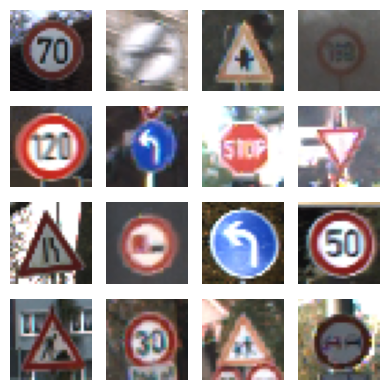

In [11]:
# 4bis. Exemples d'images du dataset GTSRB


bright_idx = [i for i in range(len(images)) if images[i].mean() > 0.3]
idx = np.random.choice(bright_idx, size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(4, 4))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(images[idx[i]])   # images normalisées [0,1]
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/archive/GTSRB/gtsrb_examples.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


In [13]:
# ============================================================
# 5. Création des datasets tf.data (batch + shuffle)
# ============================================================

batch_size = 128

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)


In [14]:
# ============================================================
# 6. Data augmentation (optionnel)
# ============================================================
# objectif : rendre le modèle plus robuste (rotations, zoom, flips légers)
#            sans recréer un nouveau dataset sur le disque

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),  # retournement horizontal aléatoire
        layers.RandomRotation(0.1),       # rotation aléatoire (±10 % de 180°)
        layers.RandomZoom(0.1),           # zoom léger aléatoire
    ],
    name="data_augmentation",
)


In [15]:
# ==========================================
# 7. Définition du modèle CNN pour GTSRB (version lite)
# ==========================================
# entrée : images 30x30x3 (RGB)
# sortie : 43 probabilités (une par classe de panneau)
# idée : remplacer Flatten + Dense par GlobalAveragePooling2D (beaucoup moins de paramètres)
# (Global pooling est une alternative recommandée à Flatten pour éviter un gros bottleneck)

img_size    = 30
num_classes = 43

# couche d'entrée
inputs = keras.Input(shape=(img_size, img_size, 3))

# bloc de data augmentation appliqué aux images d'entrée
x = data_augmentation(inputs)

# ----- bloc convolutionnel 1 -----
# deux convolutions 5x5 + ReLU
x = layers.Conv2D(32, (5, 5), activation="relu", padding="same")(x)
x = layers.Conv2D(64, (5, 5), activation="relu", padding="same")(x)
# réduction de résolution
x = layers.MaxPooling2D((2, 2))(x)
# dropout léger pour limiter le sur-apprentissage
x = layers.Dropout(0.15)(x)

# ----- bloc convolutionnel 2 -----
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.20)(x)

# ----- tête de classification (lite) -----
# remplace Flatten() + Dense(512) => beaucoup moins de paramètres
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)

# couche de sortie : 43 classes avec softmax
outputs = layers.Dense(num_classes, activation="softmax")(x)

# création du modèle Keras
model = keras.Model(inputs=inputs, outputs=outputs, name="gtsrb_cnn_lite")

# affichage du résumé du modèle (nombre de paramètres, structure)
model.summary()




Model: "gtsrb_cnn_lite"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 30, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 30, 30, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,771 (1.65 MB)

 Trainable params: 433,771 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ===========================================
# 8. Compilation et entraînement du modèle
# ===========================================
# objectif :
#  - définir l'optimiseur, la fonction de perte et les métriques
#  - utiliser des callbacks pour :
#      * sauvegarder le meilleur modèle (ModelCheckpoint)
#      * arrêter tôt si la validation ne s'améliore plus (EarlyStopping)

learning_rate = 1e-3   # taux d'apprentissage pour Adam
epochs        = 10     # nombre d'epochs (modifiable selon le temps)
batch_size    = 128    # cohérent avec la création de train_ds / val_ds

# compilation du modèle
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss="sparse_categorical_crossentropy",  # labels entiers 0..42
    metrics=["accuracy"],                    # suivi de l'accuracy en plus du loss
)

# chemin de sauvegarde du meilleur modèle (pour la suite / démo)
checkpoint_path = "best_gtsrb_cnn_tf.keras"

# définition des callbacks
callbacks = [
    # sauvegarde automatique du meilleur modèle sur la validation
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",   # critère surveillé
        save_best_only=True,      # ne garde que le meilleur modèle
        verbose=1,
    ),
    # arrêt anticipé si la val_loss ne s'améliore plus
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,               # tolère 3 epochs sans progrès
        restore_best_weights=True,
        verbose=1,
    ),
]

# entraînement du modèle sur les datasets tf.data
history = model.fit(
    train_ds,              # données d'entraînement
    validation_data=val_ds,  # données de validation
    epochs=epochs,
    callbacks=callbacks,
)
# sauvegarde de l'historique
np.save("/content/drive/MyDrive/archive/GTSRB/history_gtsrb.npy", history.history)

# sauvegarde du modèle (si pas déjà fait par ModelCheckpoint)
model.save("/content/drive/MyDrive/archive/GTSRB/best_gtsrb_cnn_tf.keras")



Epoch 1/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0941 - loss: 3.3658
Epoch 1: val_accuracy improved from -inf to 0.21933, saving model to best_gtsrb_cnn_tf.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.0942 - loss: 3.3649 - val_accuracy: 0.2193 - val_loss: 2.7703
Epoch 2/10
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2130 - loss: 2.7306
Epoch 2: val_accuracy improved from 0.21933 to 0.36572, saving model to best_gtsrb_cnn_tf.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.2133 - loss: 2.7294 - val_accuracy: 0.3657 - val_loss: 2.0796
Epoch 3/10
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3723 - loss: 2.0567
Epoch 3: val_accuracy improved from 0.36572 to 0.56733, saving model to best_gtsrb_cnn_tf.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.3727 - loss: 2.0552 - val_accuracy: 0.5673 - val_loss: 1.3349
Epoch 4/10
244/246 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5279 - loss: 1.4735
Epoch 4: val

In [17]:
# ============================================================
# 9. Sauvegarde de l'historique d'entraînement
# ============================================================
# enregistre le dictionnaire history.history dans un fichier .npy

np.save("/content/drive/MyDrive/archive/GTSRB/history_gtsrb.npy", history.history)



In [1]:
from google.colab import drive
drive.mount('/content/drive')

!rm -rf /content/GTSRB_Test_local
!mkdir -p /content/GTSRB_Test_local
!cp -r "/content/drive/MyDrive/archive/GTSRB/Test/"* /content/GTSRB_Test_local/
!ls -1 /content/GTSRB_Test_local | wc -l



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
12631


In [2]:
# ============================================================
# 11. Préparation complète du jeu de test (images + sauvegarde)
# ============================================================

import os
import numpy as np
import pandas as pd
from tensorflow import keras

# taille utilisée pendant l'entraînement
img_size = 30

# chemins
test_csv = "/content/drive/MyDrive/archive/GTSRB/Test.csv"
# ICI on pointe vers le dossier local que tu as copié
test_img_dir = "/content/GTSRB_Test_local"

# ---------- 11.1 Chargement du CSV ----------
test_df = pd.read_csv(test_csv)
test_paths = test_df["Path"].values
test_labels = test_df["ClassId"].values

print("nb images test :", len(test_paths))

# ---------- 11.2 Chargement + prétraitement complet ----------
test_images = []

for rel_path in test_paths:
    fname = os.path.basename(rel_path)
    img_path = os.path.join(test_img_dir, fname)

    img = keras.utils.load_img(img_path, target_size=(img_size, img_size))
    img = keras.utils.img_to_array(img)
    test_images.append(img)

test_images = np.array(test_images, dtype="float32") / 255.0
print("shape test_images :", test_images.shape)

# ---------- 11.3 Sauvegarde locale pour les prochaines sessions ----------
np.save("/content/test_images_30x30.npy", test_images)
np.save("/content/test_labels.npy", test_labels)







nb images test : 12630
shape test_images : (12630, 30, 30, 3)


In [3]:
from tensorflow import keras

model_path = "/content/drive/MyDrive/archive/GTSRB/best_gtsrb_cnn_tf.keras"
model = keras.models.load_model(model_path)


In [4]:

# ====================================================
# 12. Évaluation du modèle sur le jeu de test GTSRB
# ====================================================
from sklearn.metrics import accuracy_score
import numpy as np

test_preds_proba = model.predict(test_images, batch_size=128)
test_preds = np.argmax(test_preds_proba, axis=1)

test_acc = accuracy_score(test_labels, test_preds)
print(f"accuracy test : {test_acc:.4f}")


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
accuracy test : 0.8008


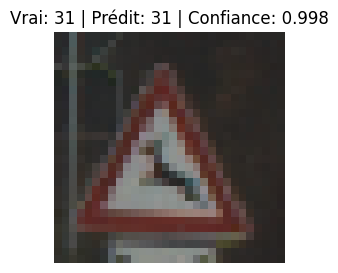

In [13]:
# ====================================================
# 12bis. Démo inférence (1 image du test)
# ====================================================

import numpy as np
import matplotlib.pyplot as plt

idx_demo = np.random.randint(0, len(test_images))
img = test_images[idx_demo]
true_label = int(test_labels[idx_demo])

proba = test_preds_proba[idx_demo]  # déjà calculé dans la section 12
pred_label = int(np.argmax(proba))
conf = float(np.max(proba))

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis("off")
plt.title(f"Vrai: {true_label} | Prédit: {pred_label} | Confiance: {conf:.3f}")
plt.show()



shape matrice de confusion : (43, 43)


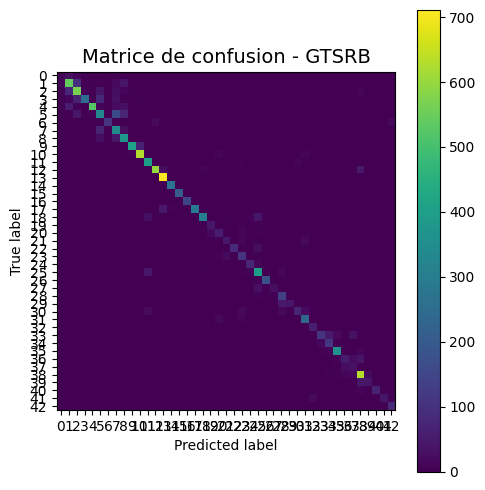

In [6]:
# ============================================================
# 13. Matrice de confusion sur le jeu de test
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# construction de la matrice de confusion (y_true = labels réels, y_pred = prédictions)
cm = confusion_matrix(test_labels, test_preds)

print("shape matrice de confusion :", cm.shape)

# affichage graphique de la matrice de confusion
plt.figure(figsize=(5, 5), facecolor="white")
ax = plt.gca()
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(
    include_values=False,
    cmap="viridis",      # ex. alternatives : "plasma", "magma", "cividis"
    ax=ax,
    colorbar=True,
)
ax.set_title("Matrice de confusion - GTSRB", fontsize=14)
ax.grid(False)           # enlève la grille
plt.tight_layout()
plt.show()





In [7]:
# ============================================================
# 14. Rapport de classification (precision, recall, f1-score)
# ============================================================

from sklearn.metrics import classification_report

# génération du rapport détaillé pour les 43 classes (labels 0..42)
print(classification_report(test_labels, test_preds))


              precision    recall  f1-score   support

           0       0.50      0.22      0.30        60
           1       0.74      0.76      0.75       720
           2       0.70      0.76      0.73       750
           3       0.96      0.56      0.71       450
           4       0.96      0.79      0.87       660
           5       0.57      0.53      0.55       630
           6       0.97      0.74      0.84       150
           7       0.54      0.76      0.63       450
           8       0.66      0.83      0.74       450
           9       0.96      0.85      0.90       480
          10       0.90      0.95      0.92       660
          11       0.80      0.95      0.87       420
          12       0.96      0.87      0.91       690
          13       0.90      0.99      0.94       720
          14       0.97      1.00      0.99       270
          15       1.00      0.98      0.99       210
          16       0.97      0.99      0.98       150
          17       1.00    

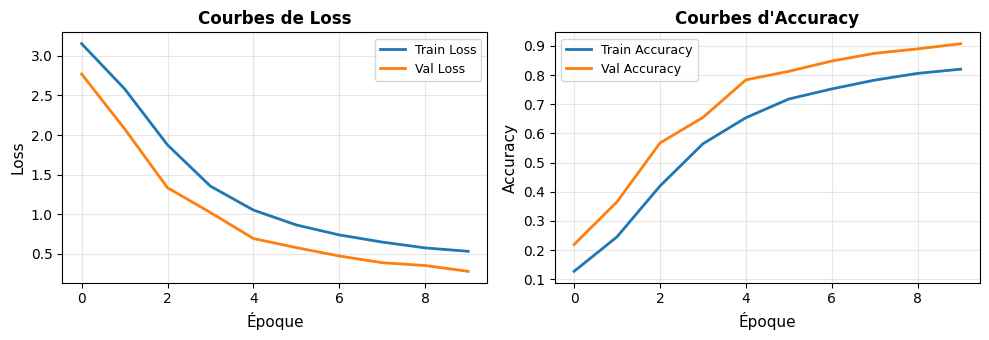

✓ Courbes d'apprentissage sauvegardées


In [10]:
# ============================================================
# 15. Visualisations complémentaires pour la présentation
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

try:
    history_dict = np.load(
        "/content/drive/MyDrive/archive/GTSRB/history_gtsrb.npy",
        allow_pickle=True
    ).item()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    axes[0].plot(history_dict["loss"], label="Train Loss", linewidth=2)
    axes[0].plot(history_dict["val_loss"], label="Val Loss", linewidth=2)
    axes[0].set_xlabel("Époque", fontsize=11)
    axes[0].set_ylabel("Loss", fontsize=11)
    axes[0].set_title("Courbes de Loss", fontsize=12, fontweight="bold")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history_dict["accuracy"], label="Train Accuracy", linewidth=2)
    axes[1].plot(history_dict["val_accuracy"], label="Val Accuracy", linewidth=2)
    axes[1].set_xlabel("Époque", fontsize=11)
    axes[1].set_ylabel("Accuracy", fontsize=11)
    axes[1].set_title("Courbes d'Accuracy", fontsize=12, fontweight="bold")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        "/content/drive/MyDrive/archive/GTSRB/learning_curves.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
    print("✓ Courbes d'apprentissage sauvegardées")
except Exception as e:
    print(f"Attention: {e}")






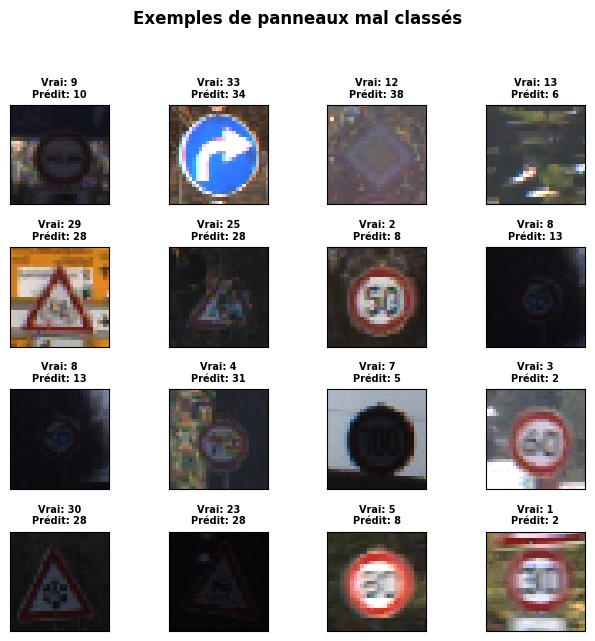

✓ Exemples mal classés sauvegardés


In [12]:
import matplotlib.pyplot as plt
import numpy as np

errors_idx = np.where(test_labels != test_preds)[0]

if len(errors_idx) > 0:
    n = min(16, len(errors_idx))
    sample_errors = np.random.choice(errors_idx, size=n, replace=False)

    fig, axes = plt.subplots(4, 4, figsize=(6.5, 6.5))
    axes = axes.flatten()

    for i, idx in enumerate(sample_errors):
        axes[i].imshow(test_images[idx])
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].set_title(
            f"Vrai: {test_labels[idx]}\nPrédit: {test_preds[idx]}",
            fontsize=7,
            fontweight="bold"
        )

    for j in range(n, 16):
        axes[j].axis("off")

    plt.suptitle("Exemples de panneaux mal classés", fontsize=12, fontweight="bold", y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(
        "/content/drive/MyDrive/archive/GTSRB/misclassified_examples.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
    print("✓ Exemples mal classés sauvegardés")
else:
    print("Aucune image mal classée !")


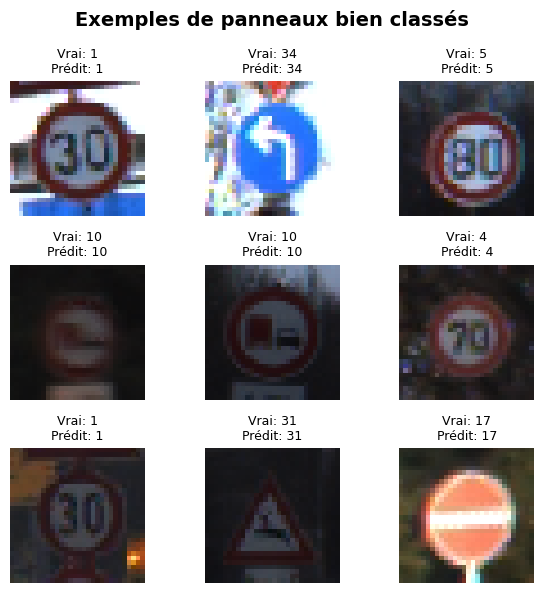

In [ ]:
# ==========================================
# 16.x Visualisation d'exemples bien prédits
# ==========================================
# Objectif :
# - Sélectionner quelques images du jeu de test correctement classées
#   par le modèle (test_labels == test_preds)
# - Afficher ces images avec leur étiquette réelle et prédite
#   pour illustrer qualitativement les bonnes prédictions

# indices des prédictions correctes
correct_idx = np.where(test_labels == test_preds)[0]

# on en prend quelques-unes au hasard
sample_correct = np.random.choice(correct_idx, size=9, replace=False)

fig = plt.figure(figsize=(6, 6))  # un peu plus petit pour réduire l’effet flou
for i, idx in enumerate(sample_correct):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[idx])  # images normalisées, pas besoin d’options
    plt.axis("off")
    plt.title(f"Vrai: {test_labels[idx]}\nPrédit: {test_preds[idx]}",
              fontsize=9)

plt.suptitle("Exemples de panneaux bien classés",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/archive/GTSRB/good_predictions.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()




In [ ]:
test_labels[idx] == test_preds[idx]


np.True_